<a href="https://colab.research.google.com/github/Vulk123/defi-ai-agent/blob/main/Eth_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas_datareader as web

In [3]:
import yfinance as yf
import datetime as dt

crypto_currency = 'ETH'
against_currency = 'USD'

start = dt.datetime(2015,1,1)
end = dt.datetime.now()

# Fetch data with yfinance instead of pandas_datareader
data = yf.download(f"{crypto_currency}-{against_currency}", start=start, end=end)
print(data.head())


/tmp/ipython-input-76151909.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{crypto_currency}-{against_currency}", start=start, end=end)
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open      Volume
Ticker         ETH-USD     ETH-USD     ETH-USD     ETH-USD     ETH-USD
Date                                                                  
2017-11-09  320.884003  329.451996  307.056000  308.644989   893249984
2017-11-10  299.252991  324.717987  294.541992  320.670990   885985984
2017-11-11  314.681000  319.453003  298.191986  298.585999   842300992
2017-11-12  307.907990  319.153015  298.513000  314.690002  1613479936
2017-11-13  316.716003  328.415009  307.024994  307.024994  1041889984


In [4]:
!pip install yfinance tensorflow scikit-learn matplotlib


In [5]:
import pandas as pd
import yfinance as yf
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential

# Crypto parameters
crypto_currency = 'ETH'
against_currency = 'USD'

# Date range
start = dt.datetime(2015,1,1)
end = dt.datetime.now()


In [6]:
data = yf.download(f"{crypto_currency}-{against_currency}", start=start, end=end)
print(data.head())


/tmp/ipython-input-4204206070.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{crypto_currency}-{against_currency}", start=start, end=end)
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open      Volume
Ticker         ETH-USD     ETH-USD     ETH-USD     ETH-USD     ETH-USD
Date                                                                  
2017-11-09  320.884003  329.451996  307.056000  308.644989   893249984
2017-11-10  299.252991  324.717987  294.541992  320.670990   885985984
2017-11-11  314.681000  319.453003  298.191986  298.585999   842300992
2017-11-12  307.907990  319.153015  298.513000  314.690002  1613479936
2017-11-13  316.716003  328.415009  307.024994  307.024994  1041889984


In [7]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data['Close'].values.reshape(-1,1))

prediction_days = 60
x_train, y_train = [], []

for x in range(prediction_days, len(scaled_data)):
    x_train.append(scaled_data[x-prediction_days:x, 0])
    y_train.append(scaled_data[x, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))


In [8]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=25, batch_size=32)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - loss: 0.0286
Epoch 2/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - loss: 0.0041
Epoch 3/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - loss: 0.0037
Epoch 4/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - loss: 0.0037
Epoch 5/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - loss: 0.0028
Epoch 6/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - loss: 0.0026
Epoch 7/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - loss: 0.0027
Epoch 8/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - loss: 0.0023
Epoch 9/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - loss: 0.0031
Epoch 10/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - loss: 0.0022
Epoch 11/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - loss: 0.0021
Epoch 12/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - loss: 0.0021
Epoch 13/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - loss: 0.0022
Epoch 14/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - loss: 0.0020
Epoch 15/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.

In [9]:
test_start = dt.datetime(2020,1,1)
test_end = dt.datetime.now()

test_data = yf.download(f"{crypto_currency}-{against_currency}", start=test_start, end=test_end)
actual_prices = test_data['Close'].values

total_dataset = pd.concat((data['Close'], test_data['Close']), axis=0)

model_inputs = total_dataset[len(total_dataset) - len(test_data) - prediction_days:].values
model_inputs = model_inputs.reshape(-1,1)
model_inputs = scaler.transform(model_inputs)

x_test = []
for x in range(prediction_days, len(model_inputs)):
    x_test.append(model_inputs[x-prediction_days:x, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))


/tmp/ipython-input-1914286055.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  test_data = yf.download(f"{crypto_currency}-{against_currency}", start=test_start, end=test_end)
[*********************100%***********************]  1 of 1 completed


65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step


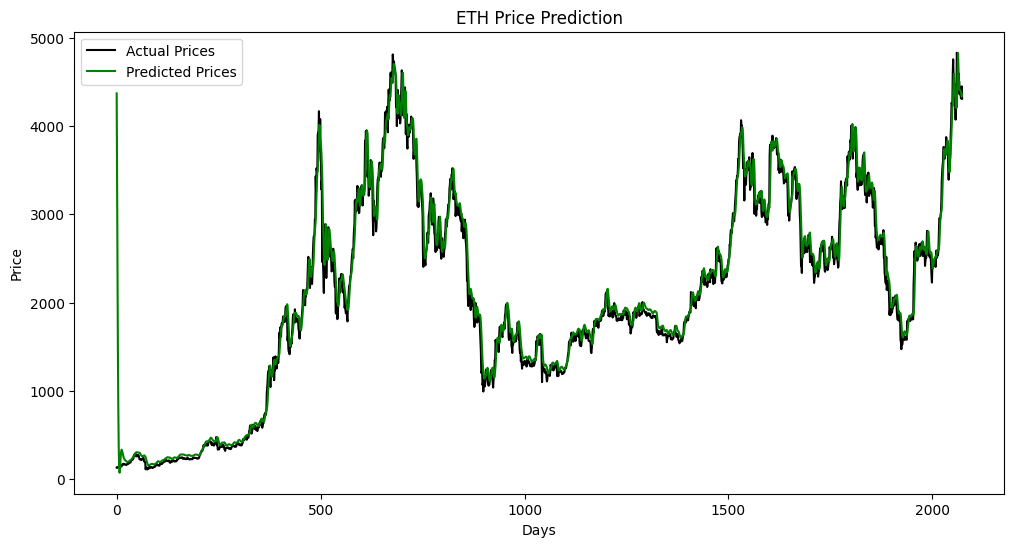

In [10]:
prediction_prices = model.predict(x_test)
prediction_prices = scaler.inverse_transform(prediction_prices)

plt.figure(figsize=(12,6))
plt.plot(actual_prices, color='black', label='Actual Prices')
plt.plot(prediction_prices, color='green', label='Predicted Prices')
plt.title(f'{crypto_currency} Price Prediction')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend(loc='upper left')
plt.show()
